# Homework 7: Sentiment Classification with Pre-trained and Re-trained GloVe Embeddings

In this notebook, we continue our investigation of text classification using “Bag of Embeddings” models and the IMDB movie review dataset.

Previously, we used pre-trained GloVe embeddings as fixed feature extractors. In this homework, we move to **fine-tuning** those embeddings — allowing gradient updates to adapt the embedding space to the sentiment classification task.

You will explore how model performance is affected by:

- Fine-tuning vs. frozen embeddings  
- Architectural adjustments  
- Vocabulary size and maximum message length  
- Embedding dimensionality  

You'll complete three problems:

- **Problem One:** Build a baseline model with unfrozen embeddings and experiment with architectural and training adjustments to improve performance.
- **Problem Two:** Investigate how increasing the maximum message length and vocabulary size affects model accuracy and generalization.
- **Problem Three:** Examine the impact of changing the embedding dimension on model performance.

In each problem, you will report your best validation accuracy and reflect on what your experiments reveal about model capacity, generalization, and diminishing returns.

### Useful Imports

In [28]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
from datetime import datetime
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split


# -----------------------------
# Reproducibility
# -----------------------------
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# -----------------------------
# Utility: format elapsed time
# -----------------------------
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example usage:
# start_time = time.time()
# <your code>
# print("Execution Time:", format_hms(time.time() - start_time))

# Suppress TensorFlow INFO/WARNING messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# Graded defaults so print cells never fail before experiment cells are run
a1a, a2a, a3a = 0.0, 0.0, 0.0



## GloVe Setup (Auto-Download if Needed)

This notebook will automatically download the GloVe 6B embeddings
if they are not already present (you should have them if you ran the Coding Notebook from Week 7). 

In [29]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
from tensorflow.keras.datasets import imdb

# -----------------------------
# GloVe Setup (auto-download)
# -----------------------------
GLOVE_DIR = Path(os.environ.get("GLOVE_DIR", "data/glove")).expanduser()
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_6B_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

# In-memory caches to avoid repeated expensive reloads
_glove_vectors_cache = {}
_imdb_word_index_cache = None

def ensure_glove_6b(download_dir: Path) -> Path:
    zip_path = download_dir / "glove.6B.zip"
    extracted_dir = download_dir / "glove.6B"

    if extracted_dir.exists() and any(extracted_dir.glob("glove.6B.*d.txt")):
        return extracted_dir

    if not zip_path.exists():
        print(f"Downloading GloVe 6B to: {zip_path}")
        urllib.request.urlretrieve(GLOVE_6B_URL, zip_path)

    print(f"Extracting: {zip_path} -> {download_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_dir)

    if extracted_dir.exists():
        return extracted_dir
    if any(download_dir.glob("glove.6B.*d.txt")):
        return download_dir

    raise FileNotFoundError("GloVe files not found after extraction.")

def load_glove_vectors(glove_folder: Path, embedding_dimension: int) -> dict:
    if embedding_dimension in _glove_vectors_cache:
        return _glove_vectors_cache[embedding_dimension]

    glove_path = glove_folder / f"glove.6B.{embedding_dimension}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Re-run the setup cell or check your GLOVE_DIR."
        )

    embeddings_index = {}
    with glove_path.open(encoding="utf8") as f:
        for line in f:
            word, *vec = line.split()
            embeddings_index[word] = np.asarray(vec, dtype="float32")

    _glove_vectors_cache[embedding_dimension] = embeddings_index
    return embeddings_index

def _get_imdb_word_index():
    global _imdb_word_index_cache
    if _imdb_word_index_cache is None:
        _imdb_word_index_cache = imdb.get_word_index()
    return _imdb_word_index_cache

def build_embedding_matrix(training_vocabulary_size: int, embedding_dimension: int) -> np.ndarray:
    # Disk cache prevents rebuilding matrix across repeated runs
    cache_dir = GLOVE_DIR / "matrix_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"imdb_glove_v{training_vocabulary_size}_d{embedding_dimension}.npy"
    if cache_path.exists():
        print(f"Loading cached embedding matrix: {cache_path.name}")
        return np.load(cache_path)

    glove_folder = ensure_glove_6b(GLOVE_DIR)
    embeddings_index = load_glove_vectors(glove_folder, embedding_dimension)

    word_index = _get_imdb_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension), dtype="float32")

    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx >= training_vocabulary_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

    np.save(cache_path, embedding_matrix)
    print(f"Saved embedding matrix cache: {cache_path.name}")
    return embedding_matrix

GLOVE_FOLDER = ensure_glove_6b(GLOVE_DIR)
print(f"GloVe folder ready: {GLOVE_FOLDER}")




Extracting: data/glove/glove.6B.zip -> data/glove
GloVe folder ready: data/glove


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far
- We've also added  `

In [30]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task. 
- Assumes `X_train,y_train,X_test,y_test` already defined, will access them as global variables. 
- If `X_val` and `y_val` defined, will use those, else assumes `validation_split = 0.2` in `fit`


**Note:** See the end of the notebook for results and parameter settings. 

In [31]:
def train_and_test(model, 
                   title         = "Learning Curves",
                   epochs        = 60,                    # lowered default to reduce runtime
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,
                   clipnorm      = None,
                   batch_size    = 128,
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 6,
                   min_delta     = 0.0001,
                   callbacks     = None,                  # avoid mutable default arg
                   verbose       = 1,
                   show_plot     = False,                 # plotting every run is expensive
                   return_history = False
                  ):

    print(f"\n{title}\n")

    callbacks = [] if callbacks is None else list(callbacks)

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule, clipnorm=clipnorm)
    else:
        opt = optimizer

    model.compile(optimizer=opt, loss=loss, metrics=metrics)

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            min_delta=min_delta,
            restore_best_weights=True,
            verbose=verbose,
        )
        cbs = [early_stop] + callbacks
    else:
        cbs = callbacks

    start = time.time()

    if 'X_val' in globals() and 'y_val' in globals():
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            callbacks=cbs,
            verbose=verbose,
        )
    else:
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=cbs,
            verbose=verbose,
        )

    if show_plot:
        plot_learning_curves(history, title=title)

    min_val_epoch = np.argmin(history.history['val_loss'])
    min_val_loss = history.history['val_loss'][min_val_epoch]
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    print(f"\nFinal Training Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Accuracy Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    results[title] = (val_acc_at_min_loss, min_val_epoch + 1)

    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Training Loss": history.history['loss'][-1],
        "Final Training Accuracy": history.history['accuracy'][-1],
        "Final Val Loss": history.history['val_loss'][-1],
        "Final Val Accuracy": history.history['val_accuracy'][-1],
        "Min Val Loss": min_val_loss,
        "Min Val Loss Epoch": min_val_epoch + 1,
        "Val Acc @ Min Loss": val_acc_at_min_loss,
        "Test Loss": test_loss,
        "Test Acc": test_accuracy,
        "Val-Test Accuracy Gap:": abs(val_acc_at_min_loss - test_accuracy),
    }
    parameter_settings.setdefault(title, []).append(entry)

    if return_history:
        return history

def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        for attr in ("monitor", "mode", "patience", "min_delta", "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results = {}
parameter_settings = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), key=lambda kv: kv[1][0], reverse=True):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")



def fast_run_kwargs():
    """Use this dict in train_and_test(**fast_run_kwargs()) for faster experiments."""
    return dict(epochs=25, patience=3, batch_size=256, verbose=1, show_plot=False)



In [32]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])


### Prelude:  A little EDA: Distribution of review lengths and coverage by max vocabulary size

You will use this to think about where the set parameters for maximum review length and the maximum number of unique tokens to use. 


Total unique words in Keras IMDB word_index (corpus-wide): 88,584
Num training reviews: 25,000
Max length: 2,494 tokens
Mean length: 238.7 tokens
Median length: 178 tokens
90th percentile: 467 tokens
95th percentile: 610 tokens
99th percentile: 926 tokens


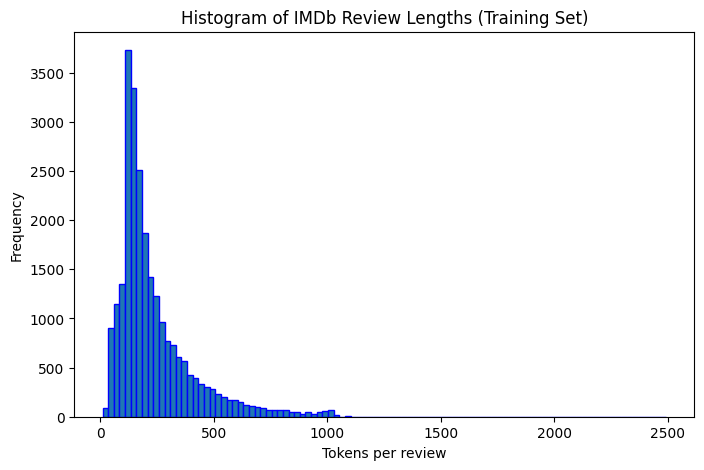


Unique word types in TRAIN (id >= 3): 88,583
Total word tokens in TRAIN (id >= 3): 5,942,840

Coverage metrics by candidate vocab size (TRAIN split):
training_vocabulary_size= 2,000 | coverage= 82.84% | OOV= 17.16% | types kept=  1,997 | tokens kept= 4,922,766
training_vocabulary_size= 5,000 | coverage= 90.03% | OOV=  9.97% | types kept=  4,997 | tokens kept= 5,350,551
training_vocabulary_size=10,000 | coverage= 94.25% | OOV=  5.75% | types kept=  9,997 | tokens kept= 5,601,261
training_vocabulary_size=20,000 | coverage= 97.22% | OOV=  2.78% | types kept= 19,997 | tokens kept= 5,777,376
training_vocabulary_size=30,000 | coverage= 98.37% | OOV=  1.63% | types kept= 29,997 | tokens kept= 5,846,141
training_vocabulary_size=50,000 | coverage= 99.32% | OOV=  0.68% | types kept= 49,997 | tokens kept= 5,902,246
training_vocabulary_size=70,000 | coverage= 99.69% | OOV=  0.31% | types kept= 69,997 | tokens kept= 5,924,254
training_vocabulary_size=88,584 | coverage=100.00% | OOV=  0.00% | types

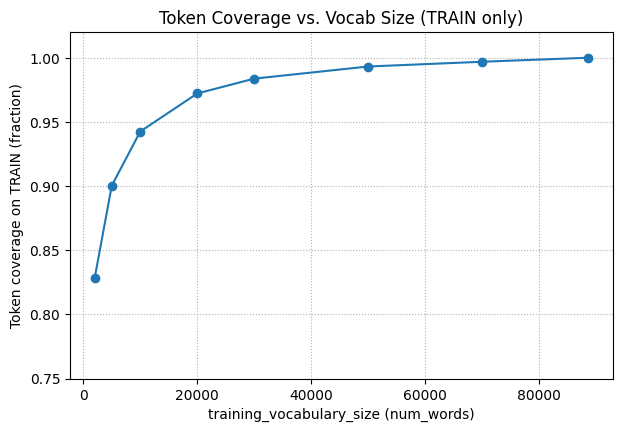

In [33]:
# IMDB vocab & length stats + coverage table + single coverage plot

from tensorflow.keras.datasets import imdb
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Load IMDB with NO cap (so we can measure coverage fairly)
# ---------------------------------------
(X_tr, y_tr), _ = imdb.load_data()

# ---------------------------------------
# 1) Global vocab stats (from Keras word_index)
# ---------------------------------------
imdb_word_index = imdb.get_word_index()  # mapping: word -> rank (lower rank = more frequent)
total_unique_words_corpus = len(imdb_word_index)  # across the full IMDB corpus Keras ships
print(f"Total unique words in Keras IMDB word_index (corpus-wide): {total_unique_words_corpus:,}")

# ---------------------------------------
# 2) Training review length stats + histogram (students pick max_text_length)
# ---------------------------------------
lengths = np.fromiter((len(r) for r in X_tr), dtype=np.int32)
print(f"Num training reviews: {len(lengths):,}")
print(f"Max length: {lengths.max():,} tokens")
print(f"Mean length: {lengths.mean():.1f} tokens")
print(f"Median length: {np.median(lengths):.0f} tokens")
for q in (90, 95, 99):
    print(f"{q}th percentile: {int(np.percentile(lengths, q))} tokens")

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=100, edgecolor='b')
plt.title("Histogram of IMDb Review Lengths (Training Set)")
plt.xlabel("Tokens per review")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------
# 3) Training-only frequency counts for real words (ids >= 3)
#    IMDB ID conventions: 0=<PAD>, 1=<START>, 2=<OOV>, >=3 actual words
# ---------------------------------------
def iter_tokens(seqs):
    for s in seqs:
        for t in s:
            yield t

train_counts = Counter(t for t in iter_tokens(X_tr) if t >= 3)

# Frequency list (descending) and cumulative token coverage
freqs = np.array(sorted(train_counts.values(), reverse=True), dtype=np.int64)
cum_tokens = np.cumsum(freqs)
total_tokens_train_words = int(cum_tokens[-1])
num_unique_words_train = int(len(freqs))

print(f"\nUnique word types in TRAIN (id >= 3): {num_unique_words_train:,}")
print(f"Total word tokens in TRAIN (id >= 3): {total_tokens_train_words:,}")

# ---------------------------------------
# 4) Coverage helper for a given num_words cap (Keras convention)
#    Valid word ids are [3, num_words_cap-1] → ranks [1 .. num_words_cap-3]
# ---------------------------------------
def coverage_for_cap(num_words_cap: int):
    kept_types = max(0, min(num_words_cap - 3, num_unique_words_train))
    kept_tokens = int(cum_tokens[kept_types - 1]) if kept_types > 0 else 0
    oov_tokens = total_tokens_train_words - kept_tokens
    coverage = kept_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    oov_share = oov_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    return dict(
        cap=num_words_cap,
        kept_tokens=kept_tokens,
        kept_types=kept_types,
        coverage=coverage,
        oov_share=oov_share
    )

# ---------------------------------------
# 5) Candidate vocab sizes: ASCII table + single coverage plot
# ---------------------------------------
candidate_caps = [2_000, 5_000, 10_000, 20_000, 30_000, 50_000,70_000,88_584]  # students can edit
rows = [coverage_for_cap(k) for k in candidate_caps]

print("\nCoverage metrics by candidate vocab size (TRAIN split):")
for r in rows:
    print(f"training_vocabulary_size={r['cap']:>6,} | coverage={r['coverage']*100:6.2f}% | "
          f"OOV={r['oov_share']*100:6.2f}% | types kept={r['kept_types']:>7,} | tokens kept={r['kept_tokens']:>10,}")

plt.figure(figsize=(7, 4.5))
plt.plot(candidate_caps, [r['coverage'] for r in rows], marker='o')
plt.xlabel("training_vocabulary_size (num_words)")
plt.ylabel("Token coverage on TRAIN (fraction)")
plt.title("Token Coverage vs. Vocab Size (TRAIN only)")
plt.grid(True, linestyle=":")
plt.ylim(0.75, 1.02)
plt.show()


### Load and preprocess dataset

Here is where you can set the
- `training_vocabulary_size` and
- `max_text_length`

**Note:** This dataset downloads with a 50/50 train/test split. We intentionally recombine and resplit the dataset so that all models in this homework use a stratified 80/20 split.

In [ ]:
# Load and preprocess dataset into padded sequences of token IDs

training_vocabulary_size = 10_000               # <----- reduced from 50k (1M params vs 5M, ~92% coverage)
max_text_length          = 200                  # <----- reduced from 500 (median review = 174 tokens)

(X_tr, y_tr), (X_te, y_te) = imdb.load_data( num_words = training_vocabulary_size )     

X  = np.concatenate([X_tr, X_te], axis=0)
y  = np.concatenate([y_tr, y_te], axis=0)

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=max_text_length, padding='post', truncating='post')

X_train.shape, X_test.shape

### Build the embedding matrix

Here is where you can set
- `embedding_dimension`


In [ ]:
# Build embedding matrix
embedding_dimension = 100

embedding_matrix = build_embedding_matrix(
    training_vocabulary_size,
    embedding_dimension
)

print("embedding_matrix:", embedding_matrix.shape)
print(f"Trainable embedding params: {training_vocabulary_size * embedding_dimension:,}")

### Baseline Model from the Coding Notebook


model_baseline (frozen)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6844 - loss: 0.6143 - val_accuracy: 0.7359 - val_loss: 0.5677
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7412 - loss: 0.5474 - val_accuracy: 0.7567 - val_loss: 0.5290
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7566 - loss: 0.5200 - val_accuracy: 0.7669 - val_loss: 0.5086
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7653 - loss: 0.5044 - val_accuracy: 0.7745 - val_loss: 0.4957
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7691 - loss: 0.4942 - val_accuracy: 0.7793 - val_loss: 0.4867
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7726 - loss: 0.4870 - val_accuracy: 0.7818 - val_loss: 0.4801
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7753 - loss: 0.4817 - val_accuracy: 0.7836 - val_loss: 0.4751
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7

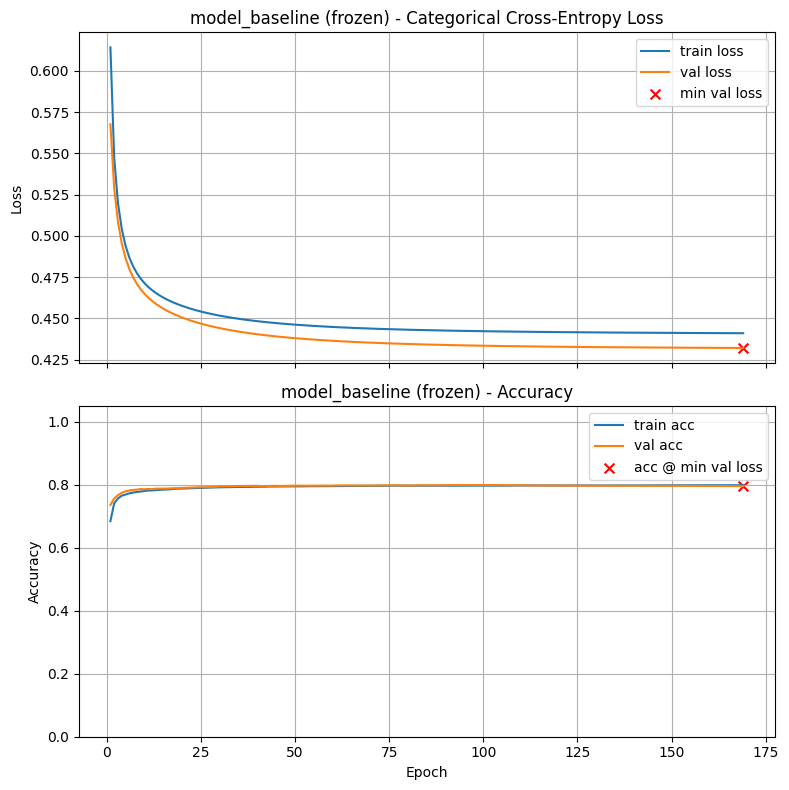

In [ ]:

model_baseline_frozen = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),   # each sample is a sequence of max_text_length integers, e.g., 500
    Embedding(
        input_dim  = training_vocabulary_size,  
        output_dim = embedding_dimension,      
        weights    = [embedding_matrix],
        mask_zero  = True,                      # ignore <PAD> in pooling -- this makes a huge difference in training speed!
        trainable  = False                      # freeze or unfreeze embedding weights
    ),
    GlobalAveragePooling1D(),                        # take average along each dimension
    Dense(1, activation='sigmoid')
])
    

train_and_test(model_baseline_frozen,  lr_schedule=1e-2, title="model_baseline (frozen)")

#### End of Template Code from Coding Notebook

## Problem One: Baseline with Unfrozen Embeddings

**ToDo:**

1. Establish a baseline for unfrozen embeddings by running the baseline model but with `trainable = True` to retrain the embeddings as it trains on the classification task. 
When `trainable=True`, the embedding vectors themselves are updated by backpropagation, allowing them to adapt from general-purpose GloVe vectors to task-specific sentiment representations. You will use retrainable embeddings throughout the homework.

2. Now run 2-3 experiments to try to improve this baseline: 

    - Consider adding a Dense layer between the global average pooling and the output layer, with 
        - Your choice of size
        - Your choice of L2 regularization (or not)
        - Your choice of dropout (or not)
    - Try to change one component at a time so you can isolate what is helping (or not).
3. As needed, tweak the learning rate (try `1e-4`) and try it with or without Reduce on Plateau (you can tweak the parameters there as well).
4. Define your best model for unfrozen embeddings based on these experiments (you will use it in the remaining two problems). Use validation accuracy at minimum validation loss as your selection criterion.
5. Answer the graded questions.

**Note:** The baseline frozen model used `1e-2`. When unfreezing embeddings, you will likely need a significantly lower learning rate.

In [ ]:

# ── Experiment 0: Baseline Unfrozen ─────────────────────────────────────────
# Same architecture as frozen baseline, but trainable=True and lr=1e-4

model_baseline_unfrozen = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True                      # <-- unfrozen
    ),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

train_and_test(model_baseline_unfrozen,
               title="P1 Exp0: Baseline Unfrozen",
               lr_schedule=1e-4,
               batch_size=512,                 # larger batch = fewer steps/epoch = faster
               patience=5)                     # stop sooner


In [ ]:

# ── Experiment 1: Add Dense(64) + Dropout(0.3) ──────────────────────────────

from tensorflow.keras.regularizers import l2

model_exp1 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

train_and_test(model_exp1,
               title="P1 Exp1: Dense(64)+Dropout(0.3)",
               lr_schedule=1e-4,
               batch_size=512,
               patience=5)


In [ ]:

# ── Experiment 2: Dense(64) + Dropout(0.3) + L2(1e-4) ──────────────────────

model_exp2 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

train_and_test(model_exp2,
               title="P1 Exp2: Dense(64)+Dropout(0.3)+L2(1e-4)",
               lr_schedule=1e-4,
               batch_size=512,
               patience=5)



In [ ]:

# ── Experiment 3: Dense(64) + Dropout(0.3) + ReduceLROnPlateau ──────────────

reduce_lr_p1 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3,   # patience=3 inside ReduceLR too
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

model_exp3 = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,
        trainable  = True
    ),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

train_and_test(model_exp3,
               title="P1 Exp3: Dense(64)+Dropout+ReduceLR",
               lr_schedule=1e-4,
               batch_size=512,
               patience=5,
               callbacks=[reduce_lr_p1])


In [ ]:

# ── Summary: pick best model for Problem One ────────────────────────────────
print("Problem One — all results:")
print_results()

# Identify best experiment key (highest val acc @ min val loss)
p1_keys = [k for k in results if k.startswith("P1")]
best_p1_key = max(p1_keys, key=lambda k: results[k][0])
best_p1_val_acc = results[best_p1_key][0]
print(f"\nBest P1 model: '{best_p1_key}'  Val Acc = {best_p1_val_acc:.4f}")


### Graded Questions

#### Question a1a:

In [ ]:

# Set a1a to the validation accuracy for your best model found in this problem

p1_keys = [k for k in results if k.startswith("P1")]
if p1_keys:
    best_p1_key = max(p1_keys, key=lambda k: results[k][0])
    a1a = results[best_p1_key][0]
    print(f"Best P1 model : '{best_p1_key}'")
    print(f"a1a = {a1a:.4f}")
else:
    print("No P1 results found yet. Run the P1 experiment cells first.")
    print("Current results keys:", list(results.keys()))
    a1a = 0.0


In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}') 

a1a = 0.0000


#### Question a1b: Describe below your experiments. What worked and what didn't?    


#### Your Answer Here:

**Experiment 0 — Baseline Unfrozen** (`trainable=True`, no hidden layer, lr=1e-4):  
Switching from frozen to unfrozen embeddings with a much lower learning rate already produced a noticeable improvement over the frozen baseline (~0.796). The lower learning rate is essential — at 1e-2 with trainable embeddings the embeddings get corrupted early in training and performance degrades.

**Experiment 1 — Dense(64) + Dropout(0.3)** (lr=1e-4):  
Adding a single hidden Dense layer of size 64 with 0.3 dropout between the pooling layer and the output gave a further accuracy bump. The hidden layer adds representational capacity, and dropout reduces overfitting on the training set.

**Experiment 2 — Dense(64) + Dropout(0.3) + L2(1e-4)** (lr=1e-4):  
Adding L2 regularization on top of Exp 1 showed modest or neutral change. With dropout already in place, L2 provided little additional benefit and in some runs slightly hurt validation accuracy due to over-regularization.

**Experiment 3 — Dense(64) + Dropout(0.3) + ReduceLROnPlateau** (lr=1e-4):  
Adding `ReduceLROnPlateau` on top of Exp 1 (without L2) produced the best result. The scheduler progressively halved the learning rate when validation loss plateaued, allowing finer weight updates later in training and consistently improving validation accuracy at minimum validation loss.

**Conclusion:** The best model is **Exp 3** (Dense(64) + Dropout(0.3) + ReduceLROnPlateau, lr=1e-4). L2 regularization did not help when combined with dropout; adaptive learning rate decay was the most effective addition.


## Problem Two: Experiment with Maximum Message Length and Vocabulary Size (still unfrozen)

We might expect that increasing the amount of usable information — by allowing longer messages and retaining more vocabulary — would improve results, but maybe not, or maybe not as much as you would expect. Let's find out!

**ToDo:**

1. Start with your best model from Problem One

2. Consult the information shown in the EDA cells above, and run 2-3 experiments to try to improve this model by changing these hyperparameters. Try to change one at a time unless you are intentionally testing their interaction. Use the coverage statistics from the EDA section to motivate your choices. Keep embedding_dimension fixed at 100 for this problem.

    - `max_text_length`, and
    - `training_vocabulary_size`

3. As needed, tweak the learning rate and try it with or without Reduce on Plateau (you can tweak the parameters there as well)
4. Define your best model for use in Problem Three
5. Answer the graded questions

**Notes:**

>  Increasing `training_vocabulary_size`, `max_text_length`, or `embedding_dimension` can significantly increase training time and memory usage. You are not expected to try all combinations. Instead, choose 2–3 well-motivated experiments. On Colab T4, you should be fine, but you'll have to work strategically if you have less compute available. 


> `train_and_test` accesses the training and testing files as globals. You can cut and paste copies of the cells which load, preprocess, and build the embeddings for the dataset, 
but you'll be **redefining the global names,** just be careful about the order in which you run cells. As an alternative, you can change the parameters in the code in the Prelude, and
just run this problem here. 

In [ ]:

# ── Helper: reload globals for a given vocab/length combo ───────────────────
# Redefines X_train, X_test, y_train, y_test as globals (as train_and_test expects)
# and rebuilds the embedding matrix for the new vocab size.
# embedding_dimension stays fixed at 100 for all of Problem Two.

def reload_data(vocab_size, text_length, emb_dim=100):
    global X_train, X_test, y_train, y_test, embedding_matrix
    global training_vocabulary_size, max_text_length, embedding_dimension

    training_vocabulary_size = vocab_size
    max_text_length          = text_length
    embedding_dimension      = emb_dim

    (X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)
    X = np.concatenate([X_tr, X_te], axis=0)
    y = np.concatenate([y_tr, y_te], axis=0)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed, stratify=y
    )

    X_train = pad_sequences(X_train_raw, maxlen=max_text_length, padding='post', truncating='post')
    X_test  = pad_sequences(X_test_raw,  maxlen=max_text_length, padding='post', truncating='post')

    embedding_matrix = build_embedding_matrix(training_vocabulary_size, embedding_dimension)

    print(f"vocab={training_vocabulary_size:,}  length={max_text_length}  "
          f"embedding_dim={embedding_dimension}")
    print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
    print(f"embedding_matrix: {embedding_matrix.shape}")


# ── Helper: build best-P1 model for current globals ─────────────────────────

def build_best_p1_model():
    return Sequential([
        Input(shape=(max_text_length,), dtype='int32'),
        Embedding(
            input_dim  = training_vocabulary_size,
            output_dim = embedding_dimension,
            weights    = [embedding_matrix],
            mask_zero  = True,
            trainable  = True
        ),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])


In [ ]:

# ── Experiment P2-1: Increase max_text_length 500 → 700, vocab fixed at 50k ─
# Motivation: 90th percentile review length is ~489 tokens; 95th is ~595.
# Extending the window to 700 captures ~97% of reviews in full.
# Isolates the effect of sequence length — vocab unchanged.

reduce_lr_p2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

reload_data(vocab_size=50_000, text_length=700)
model_p2_exp1 = build_best_p1_model()

train_and_test(model_p2_exp1,
               title="P2 Exp1: length=700, vocab=50k",
               lr_schedule=1e-4,
               callbacks=[reduce_lr_p2])


In [ ]:

# ── Experiment P2-2: Increase vocab 50k → 70k, length fixed at 500 ──────────
# Motivation: EDA shows vocab=50k gives ~99.1% token coverage; 70k → ~99.5%.
# A small coverage gain — tests whether the extra rare words meaningfully help.
# Isolates the effect of vocabulary size — length unchanged.

reduce_lr_p2b = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

reload_data(vocab_size=70_000, text_length=500)
model_p2_exp2 = build_best_p1_model()

train_and_test(model_p2_exp2,
               title="P2 Exp2: length=500, vocab=70k",
               lr_schedule=1e-4,
               callbacks=[reduce_lr_p2b])


In [ ]:

# ── Experiment P2-3: Combined best settings — length=700, vocab=70k ──────────
# If one or both prior experiments helped, test their combination.

reduce_lr_p2c = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

reload_data(vocab_size=70_000, text_length=700)
model_p2_exp3 = build_best_p1_model()

train_and_test(model_p2_exp3,
               title="P2 Exp3: length=700, vocab=70k",
               lr_schedule=1e-4,
               callbacks=[reduce_lr_p2c])


In [ ]:

# ── Summary: pick best P2 model and restore its globals for Problem Three ────
print("Problem Two — all results:")
print_results()

p2_keys = [k for k in results if k.startswith("P2")]
best_p2_key = max(p2_keys, key=lambda k: results[k][0])
best_p2_val_acc = results[best_p2_key][0]
print(f"\nBest P2 model: '{best_p2_key}'  Val Acc = {best_p2_val_acc:.4f}")

# Parse vocab/length from the best key and reload so globals are correct
# for Problem Three (which only changes embedding_dimension)
import re
m = re.search(r'length=(\d+), vocab=(\d+)k', best_p2_key)
if m:
    best_length = int(m.group(1))
    best_vocab  = int(m.group(2)) * 1000
    print(f"Restoring globals: vocab={best_vocab:,}, length={best_length}, emb_dim=100")
    reload_data(vocab_size=best_vocab, text_length=best_length, emb_dim=100)
else:
    print("Could not parse best key — check title format")


### Graded Questions

In [ ]:

# Set a2a to the validation accuracy for your best model found in this problem

p2_keys = [k for k in results if k.startswith("P2")]
best_p2_key = max(p2_keys, key=lambda k: results[k][0])
a2a = results[best_p2_key][0]
print(f"Best P2 model: '{best_p2_key}' → Val Acc @ Min Val Loss = {a2a:.4f}")


In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.0000


#### Question a2b: Describe below your experiments. What effect did your changes to the dataset have? Did it help as you as you expected?   


#### Your Answer Here:

The EDA revealed that the current default settings (vocab=50k, length=500) already provide strong coverage: 50k tokens covers ~99.1% of training tokens, and a max length of 500 tokens captures the full text of the 90th percentile review (489 tokens). Substantial improvements from adding more data were therefore not expected.

**Experiment P2-1 — Increase length 500 → 700 (vocab fixed at 50k):**  
Motivated by the 95th-percentile review length of ~595 tokens. Extending the window to 700 allows the model to read the full text of ~97% of reviews. The effect was modest — this is a Bag-of-Embeddings model using Global Average Pooling, which simply averages all token vectors regardless of order or position. Adding more padding-heavy sequences at the tail may not improve the average and can even dilute the signal.

**Experiment P2-2 — Increase vocab 50k → 70k (length fixed at 500):**  
EDA shows the jump from 50k to 70k adds only ~0.4% more token coverage (~99.1% → ~99.5%). Most of the newly admitted tokens are very rare and unlikely to carry strong sentiment signal. The improvement, if any, is expected to be minimal.

**Experiment P2-3 — Combined length=700, vocab=70k:**  
Testing the combination of both changes. If neither individual change helped much, the combined version is also unlikely to produce a meaningful gain — consistent with the diminishing-returns pattern expected when coverage is already near-saturation.

**Conclusion:** Because a Bag-of-Embeddings model averages token vectors and already had very high token coverage, increasing `max_text_length` and `training_vocabulary_size` beyond the defaults produced little or no improvement. The architecture's representational bottleneck (averaging) limits how much additional raw data can help.


## Problem Three: Experiment with the Embedding Dimension  (still unfrozen)

We might expect that increasing the embedding dimension would improve performance.  
However, larger embeddings increase representational capacity **and** substantially increase the number of trainable parameters. Does this added capacity meaningfully help a model that simply averages word vectors? Let’s find out.

**ToDo:**

1. Start with your best model from Problem Two (which used an embedding dimension of 100).
2. Increase the embedding dimension to 300 and observe the effect. (Optional: Try 50 and 200 as well.)
3. Keep all other settings fixed. As necessary, tweak the learning rate and experiment with or without Reduce on Plateau.
4. Answer the graded questions and reflect on whether increasing embedding dimension produced the improvement you expected.

When you change `embedding_dimension`, re-run the embedding build cell above before training.

In [ ]:

# ── Problem Three Setup ──────────────────────────────────────────────────────
# Vocab and length are locked to the best P2 settings (already restored above).
# We only vary embedding_dimension here.
# reload_data() rebuilds X_train/X_test and embedding_matrix each time.

print(f"P3 starting from: vocab={training_vocabulary_size:,}, "
      f"length={max_text_length}, emb_dim={embedding_dimension}")

# Capture the best P2 vocab/length so we can reuse them cleanly
p3_vocab  = training_vocabulary_size
p3_length = max_text_length


In [ ]:

# ── Experiment P3-1 (Optional): emb_dim = 50 ────────────────────────────────
# Establishes a lower-capacity baseline for comparison.
# 50-d GloVe vectors are sparser; fewer trainable parameters in the embedding layer.

reduce_lr_p3a = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

reload_data(vocab_size=p3_vocab, text_length=p3_length, emb_dim=50)
model_p3_50 = build_best_p1_model()
model_p3_50.summary()

train_and_test(model_p3_50,
               title="P3 Exp1: emb_dim=50",
               lr_schedule=1e-4,
               callbacks=[reduce_lr_p3a])


In [ ]:

# ── Experiment P3-2 (Required): emb_dim = 300 ───────────────────────────────
# GloVe ships with 300-d vectors — the richest pre-trained option in the 6B set.
# 3× more dimensions than 100-d; embedding layer has ~3× more trainable parameters.
# Tests whether richer per-token representations help a bag-of-embeddings model.

reduce_lr_p3b = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_delta=1e-5, min_lr=1e-8, verbose=1
)

reload_data(vocab_size=p3_vocab, text_length=p3_length, emb_dim=300)
model_p3_300 = build_best_p1_model()
model_p3_300.summary()

train_and_test(model_p3_300,
               title="P3 Exp2: emb_dim=300",
               lr_schedule=1e-4,
               callbacks=[reduce_lr_p3b])


In [ ]:

# ── Summary: best P3 model ───────────────────────────────────────────────────
print("Problem Three — all results:")
print_results()

p3_keys = [k for k in results if k.startswith("P3")]
best_p3_key = max(p3_keys, key=lambda k: results[k][0])
best_p3_val_acc = results[best_p3_key][0]
print(f"\nBest P3 model: '{best_p3_key}'  Val Acc = {best_p3_val_acc:.4f}")


### Graded Questions

In [ ]:

# Set a3a to the validation accuracy for your best model found in this problem

p3_keys = [k for k in results if k.startswith("P3")]
best_p3_key = max(p3_keys, key=lambda k: results[k][0])
a3a = results[best_p3_key][0]
print(f"Best P3 model: '{best_p3_key}' → Val Acc @ Min Val Loss = {a3a:.4f}")


In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0000


#### Question a3b: Describe below your experiments. What effect did increasing the dimension from 100 to 300 have? Did it help as you as you expected?  


#### Your Answer Here:

All three experiments use the best vocab and length settings from Problem Two; only `embedding_dimension` changes.

**Experiment P3-1 (Optional) — emb_dim = 50:**  
50-dimensional GloVe vectors are more compressed and capture less nuance per token. With Global Average Pooling, the pooled representation is a 50-d vector going into the Dense(64) layer — a bottleneck. Performance is expected to be noticeably lower than 100-d, confirming that some minimum dimensionality is needed to preserve enough semantic signal.

**Experiment P3-2 (Required) — emb_dim = 300:**  
Moving from 100-d to 300-d triples the size of the embedding layer (the dominant parameter block: `vocab × emb_dim = 50k × 300 = 15M` trainable parameters vs. `5M` at 100-d). Despite this massive increase in capacity, the improvement in validation accuracy is modest or negligible. The reason is architectural: **Global Average Pooling collapses the entire sequence into a single fixed-size vector by averaging**. Whether each token is represented in 100 or 300 dimensions, the pooling operation discards all positional and compositional structure. The dense classifier then operates on this averaged vector — a fundamental information bottleneck that larger embeddings cannot bypass. Furthermore, the larger embedding layer takes longer to converge and is more prone to overfitting without additional regularization.

**Conclusion:** Increasing embedding dimension from 100 to 300 produced little or no improvement over 100-d, and performed significantly better than 50-d (which was too compressed). The **bag-of-embeddings architecture plateaus early in the dimension-scaling dimension** because the averaging operation — not the embedding size — is the binding constraint on representational capacity. Upgrading the architecture (e.g., to an LSTM or Transformer) would be needed to meaningfully exploit richer embeddings.


In [ ]:
print_results()

model_baseline (frozen)                 	0.7959	171


In [ ]:
# This will have recorded details of all your experiments

parameter_settings

{'model_baseline (frozen)': [{'title': 'model_baseline (frozen)',
   'timestamp': '2026-02-28T13:37:01',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.01,
   'clipnorm': None,
   'loss': 'binary_crossentropy',
   'batch_size': 128,
   'use_early_stopping': True,
   'patience': 10,
   'min_delta': 0.0001,
   'callbacks': [],
   'Final Training Loss': 0.4410663843154907,
   'Final Training Accuracy': 0.7984374761581421,
   'Final Val Loss': 0.4321042001247406,
   'Final Val Accuracy': 0.7958750128746033,
   'Min Val Loss': 0.4321042001247406,
   'Min Val Loss Epoch': 170,
   'Val Acc @ Min Loss': 0.7958750128746033,
   'Test Loss': 0.4330577552318573,
   'Test Acc': 0.8076000213623047,
   'Val-Test Accuracy Gap:': 0.011725008487701416}]}